# Лабораторная работа №4
## Выполнил: Лавренов М.А.
## Группа: ИУ5-23М

## Методы поиска условного экстремума

**Вариант 5.**

Целевая функция (Розенброк, $n=3$):
$$f(x) = \sum_{i=1}^{n-1}\left[a(x_i^2 - x_{i+1})^2 + b(x_i-1)^2\right] + f_0,
\qquad a=70,\ b=5,\ f_0=30,\ n=3.$$

Ограничения:
$$g_1(x) = x_1^2 + x_2^2 - 3x_3 - 5 \le 0,\quad
g_2(x) = -x_1 \le 0,\quad
g_3(x) = -x_2 \le 0,\quad
g_4(x) = -x_3 \le 0.$$

Все ограничения — типа неравенств ($l=0$, $m=4$).

### Что нужно сделать
1. Реализовать пять методов: внешних штрафов, барьеров, комбинированный, модифицированных функций Лагранжа, проекции градиента.
2. Найти стационарную точку и значение функции в ней.
3. Сравнить методы по точности и скорости сходимости.
4. Проверить допустимость решения.

### Предварительный анализ
Безусловный минимум функции Розенброка — в точке $(1,1,1)$, $f=f_0=30$. Подставим в $g_1$: $1+1-3-5 = -6 \le 0$, остальные ограничения тоже выполнены с запасом. Значит **условный минимум совпадает с безусловным**: $x^* = (1,1,1)^T$, $f^* = 30$. Все ограничения в решении неактивны, множители Лагранжа равны нулю.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.set_printoptions(precision=6, suppress=True)

# Параметры варианта 5
a, b, f0, n = 70, 5, 30, 3

def f(x):
    s = 0.0
    for i in range(n-1):
        s += a*(x[i]**2 - x[i+1])**2 + b*(x[i]-1)**2
    return s + f0

def grad_f(x):
    g = np.zeros(n)
    # вклад от членов i = 0..n-2
    for i in range(n-1):
        # d/dx_i: 4a(x_i^2 - x_{i+1}) * x_i + 2b(x_i - 1)
        g[i]   += 4*a*(x[i]**2 - x[i+1])*x[i] + 2*b*(x[i] - 1)
        # d/dx_{i+1}: -2a(x_i^2 - x_{i+1})
        g[i+1] += -2*a*(x[i]**2 - x[i+1])
    return g

# Ограничения g_j(x) <= 0
def g1(x): return x[0]**2 + x[1]**2 - 3*x[2] - 5
def g2(x): return -x[0]
def g3(x): return -x[1]
def g4(x): return -x[2]
G = [g1, g2, g3, g4]

def grad_g1(x): return np.array([2*x[0], 2*x[1], -3.0])
def grad_g2(x): return np.array([-1.0, 0.0, 0.0])
def grad_g3(x): return np.array([0.0, -1.0, 0.0])
def grad_g4(x): return np.array([0.0, 0.0, -1.0])
GRAD_G = [grad_g1, grad_g2, grad_g3, grad_g4]

def feasible(x, tol=1e-8):
    return all(g(x) <= tol for g in G)

def violation(x):
    return max(0.0, max(g(x) for g in G))

# Эталонное решение
x_star = np.array([1.0, 1.0, 1.0])
print(f"Безусловный минимум:  x* = {x_star},  f* = {f(x_star)}")
print(f"Допустим:             {feasible(x_star)}")
print(f"Значения ограничений: {[g(x_star) for g in G]}")


Безусловный минимум:  x* = [1. 1. 1.],  f* = 30.0
Допустим:             True
Значения ограничений: [np.float64(-6.0), np.float64(-1.0), np.float64(-1.0), np.float64(-1.0)]


## Вспомогательный модуль: безусловная минимизация

Для решения вспомогательных подзадач используем градиентный метод BFGS из `scipy.optimize`. По заданию (Замечание 4.3) разрешён любой известный метод безусловного поиска. Везде передаём аналитический градиент — это и быстрее, и устойчивее.


In [ ]:
def unconstrained_min(F, x0, grad_F=None, tol=1e-7, maxiter=500):
    # Обёртка над scipy BFGS. Возвращает (x*, F*).
    res = minimize(F, x0, jac=grad_F, method='BFGS',
                   options={'gtol': tol, 'maxiter': maxiter})
    return res.x, res.fun


**Замечание о вырожденности задачи варианта 5.** Безусловный минимум $f$ — точка $(1,1,1)$ — лежит строго внутри допустимой области и является также глобальным минимумом любой вспомогательной функции $F(x, r) = f(x) + P(x, r)$ при $P(x,r)\equiv 0$ в этой точке. Поэтому *любой* достаточно мощный метод безусловной минимизации (BFGS, Ньютон) при первом же запуске вспомогательной задачи попадает в окрестность $(1,1,1)$, и алгоритмы метода штрафов / модифицированного Лагранжа сходятся **за один внешний шаг**. Чтобы наглядно увидеть многошаговую динамику, искусственно ограничиваем число внутренних итераций BFGS первых внешних шагов — тогда подзадачи решаются неточно (что в реальности рекомендуется и в самом методе, см. п. 5 раздела «Сходимость» в методичке: «нет необходимости решать их точно»).

In [ ]:
def unconstrained_min_limited(F, x0, grad_F=None, tol=1e-6, maxiter=3):
    # ограниченное число итераций BFGS - чтобы видеть промежуточные точки
    res = minimize(F, x0, jac=grad_F, method='BFGS',
                   options={'gtol': tol, 'maxiter': maxiter})
    return res.x, res.fun


## 1. Метод внешних штрафов

Все ограничения — неравенства, поэтому штраф — квадрат срезки:
$$P(x, r) = \frac{r}{2}\sum_{j=1}^{m}\bigl[\max(0,\, g_j(x))\bigr]^2.$$

Вспомогательная функция $F(x,r) = f(x) + P(x,r)$ минимизируется по $x$, затем $r$ увеличивается в $C$ раз. Алгоритм останавливается, когда $P(x^*, r) \le \varepsilon$.

Стартовая точка $x^0 = (-1, -1, -1)$ — заведомо вне допустимой области (нарушает $g_2, g_3, g_4$), чтобы наглядно видеть, как точки приближаются к области извне.


In [ ]:
def penalty_external(x0, r0=1.0, C=5.0, eps=1e-4, max_outer=15, verbose=False):
    r = r0
    x = np.array(x0, dtype=float)
    history = []  # (k, r, x, f, P, violation)
    x_prev = None

    for k in range(max_outer):
        def F(x):
            pen = 0.5 * r * sum(max(0.0, gj(x))**2 for gj in G)
            return f(x) + pen
        def grad_F(x):
            g = grad_f(x).copy()
            for gj, dgj in zip(G, GRAD_G):
                gv = gj(x)
                if gv > 0:
                    g += r * gv * dgj(x)
            return g

        # на ранних итерациях ограничиваем число шагов BFGS
        x, _ = unconstrained_min_limited(F, x, grad_F=grad_F, maxiter=4) \
               if k < max_outer-3 else unconstrained_min(F, x, grad_F=grad_F)
        P = 0.5 * r * sum(max(0.0, gj(x))**2 for gj in G)
        history.append((k, r, x.copy(), f(x), P, violation(x)))
        if verbose:
            print(f"k={k:2d}  r={r:10.2f}  x={x}  f={f(x):.6f}  P={P:.2e}  наруш={violation(x):.2e}")
        # двойной критерий: малый штраф И малое изменение x
        if P <= eps and x_prev is not None and np.linalg.norm(x - x_prev) < 1e-5:
            break
        x_prev = x.copy()
        r *= C
    return x, history

# Стартовая точка нарушает несколько ограничений: g1(2,2,-0.5)=4+4+1.5-5=4.5>0; g4=0.5>0
x0_pen = [2.0, 2.0, -0.5]
print(f"x0 = {x0_pen}, ограничения: {[round(g(np.array(x0_pen)),3) for g in G]}\n")
x_ext, hist_ext = penalty_external(x0_pen, r0=1.0, C=5.0, eps=1e-6, verbose=True)
print()
print(f"Решение:  x* = {x_ext}")
print(f"f(x*)  = {f(x_ext):.8f}")
print(f"Допустимость (max нарушение): {violation(x_ext):.2e}")


x0 = [2.0, 2.0, -0.5], ограничения: [np.float64(4.5), np.float64(-2.0), np.float64(-2.0), np.float64(0.5)]

k= 0  r=      1.00  x=[1.306281 1.550864 2.170427]  f=37.536622  P=0.00e+00  наруш=0.00e+00
k= 1  r=      5.00  x=[1.135943 1.288316 1.649641]  f=30.515493  P=0.00e+00  наруш=0.00e+00
k= 2  r=     25.00  x=[1.060418 1.123742 1.250204]  f=30.105950  P=0.00e+00  наруш=0.00e+00
k= 3  r=    125.00  x=[1.019868 1.039749 1.079088]  f=30.010161  P=0.00e+00  наруш=0.00e+00
k= 4  r=    625.00  x=[1.011828 1.024281 1.050337]  f=30.003762  P=0.00e+00  наруш=0.00e+00
k= 5  r=   3125.00  x=[1.007046 1.014121 1.028541]  f=30.001246  P=0.00e+00  наруш=0.00e+00
k= 6  r=  15625.00  x=[0.999944 0.999863 0.999606]  f=30.000001  P=0.00e+00  наруш=0.00e+00
k= 7  r=  78125.00  x=[1. 1. 1.]  f=30.000000  P=0.00e+00  наруш=0.00e+00
k= 8  r= 390625.00  x=[1. 1. 1.]  f=30.000000  P=0.00e+00  наруш=0.00e+00

Решение:  x* = [1. 1. 1.]
f(x*)  = 30.00000000
Допустимость (max нарушение): 0.00e+00


**Что видно.** С каждой итерацией штраф растёт, точка втягивается внутрь допустимой области, $f(x^k)$ монотонно приближается к 30. В нашем варианте, поскольку безусловный минимум лежит внутри $X$ с большим запасом, итераты быстро попадают в область, и характерный для метода штрафов «дефект» (точки приходят к решению извне, ограничения чуть-чуть нарушены) проявляется только на самой первой итерации. Уже начиная со второй итерации все ограничения выполнены строго.

## 2. Метод барьерных функций

Используем логарифмический барьер:
$$P(x, r) = -r \sum_{j=1}^{m} \ln\bigl(-g_j(x)\bigr).$$

Барьер определён только во **внутренних** точках области ($g_j(x) < 0$), поэтому стартовать нужно изнутри. Возьмём $x^0 = (0.5,\, 0.5,\, 1.0)$: проверяем — $g_1 = 0.25+0.25-3-5 = -7.5 < 0$, $x_i > 0$ для всех $i$. Подходит.

Параметр $r$ **уменьшается** в $C$ раз на каждой итерации. Условие останова: $|P(x^*, r)| \le \varepsilon$.

В функции `unconstrained_min` нужно следить, чтобы шаг не выпрыгнул за границу. Простейший приём — возвращать $+\infty$ при попытке вычислить барьер вне области; BFGS корректно отрежет такие шаги через линейный поиск.


In [ ]:
def barrier_log(x0, r0=1.0, C=10.0, eps=1e-4, max_outer=30, verbose=False):
    assert feasible(x0) and all(g(x0) < 0 for g in G), "x0 должна быть строго внутри X"
    r = r0
    x = np.array(x0, dtype=float)
    history = []

    for k in range(max_outer):
        def F(x):
            # если вышли за границу - штрафуем бесконечностью
            for gj in G:
                if gj(x) >= 0:
                    return 1e18
            return f(x) - r * sum(np.log(-gj(x)) for gj in G)
        def grad_F(x):
            for gj in G:
                if gj(x) >= 0:
                    return np.zeros(n)  # не используется, т.к. F=inf
            g = grad_f(x).copy()
            for gj, dgj in zip(G, GRAD_G):
                g += -r * dgj(x) / (-gj(x))  # = r * dg/(-g)... разберём знаки:
                # d/dx [-r ln(-g)] = -r * (1/(-g)) * (-1) * dg = r * dg / (-g) ... wait
            return g

        # перепишем grad_F аккуратно
        def grad_F(x):
            for gj in G:
                if gj(x) >= 0:
                    return np.zeros(n)
            grad = grad_f(x).copy()
            for gj, dgj in zip(G, GRAD_G):
                # F содержит -r * ln(-g_j(x))
                # производная: -r * (1/(-g_j)) * d(-g_j)/dx = -r * (1/(-g_j)) * (-dg_j) = -r * dg_j / g_j
                grad += -r * dgj(x) / gj(x)
            return grad

        x, _ = unconstrained_min(F, x, grad_F=grad_F)
        P = -r * sum(np.log(-gj(x)) for gj in G)
        history.append((k, r, x.copy(), f(x), P, violation(x)))
        if verbose:
            print(f"k={k:2d}  r={r:10.6f}  x={x}  f={f(x):.6f}  |P|={abs(P):.2e}")
        if abs(P) <= eps:
            break
        r /= C
    return x, history

x_bar, hist_bar = barrier_log([0.5, 0.5, 1.0], r0=1.0, C=10.0, eps=1e-3, verbose=True)
print()
print(f"Решение:  x* = {x_bar}")
print(f"f(x*)  = {f(x_bar):.8f}")
print(f"Допустимость: {feasible(x_bar)},  значения g: {[round(gj(x_bar),4) for gj in G]}")


k= 0  r=  1.000000  x=[1.128356 1.275465 1.634241]  f=30.466008  |P|=2.80e+00
k= 1  r=  0.100000  x=[1.015442 1.031437 1.064884]  f=30.006214  |P|=1.92e-01
k= 2  r=  0.010000  x=[1.001582 1.0032   1.006517]  f=30.000065  |P|=1.80e-02
k= 3  r=  0.001000  x=[1.000159 1.000321 1.000652]  f=30.000001  |P|=1.79e-03
k= 4  r=  0.000100  x=[1.000016 1.000032 1.000065]  f=30.000000  |P|=1.79e-04

Решение:  x* = [1.000016 1.000032 1.000065]
f(x*)  = 30.00000001
Допустимость: True,  значения g: [np.float64(-6.0001), np.float64(-1.0), np.float64(-1.0), np.float64(-1.0001)]


**Что видно.** В отличие от внешних штрафов точки **всегда допустимы**. С уменьшением $r$ барьер ослабевает, и решение может приближаться к границе (в нашем случае оно лежит внутри, поэтому такой эффект слабый). Сходимость к $(1,1,1)$ устойчивая.

## 3. Комбинированный метод (внешний штраф + барьер)

В стандартной задаче применяется, когда часть ограничений «жёсткая» (нельзя нарушать — барьер), а часть «мягкая» (можно временно нарушать — штраф). У нас $g_1$ — содержательное ограничение, $g_2, g_3, g_4$ — простая неотрицательность переменных. Логично барьерами держать неотрицательность ($x_i > 0$), а $g_1$ штрафовать снаружи.

$$F(x, r_p, r_b) = f(x) + \tfrac{r_p}{2}[\max(0,g_1(x))]^2 - r_b \sum_{j=2}^{4}\ln(-g_j(x)).$$

Используем **два независимых параметра**: штрафной $r_p$ растёт ($\times C$), барьерный $r_b$ убывает ($\times 1/C$).


In [ ]:
def combined(x0, rp0=1.0, rb0=1.0, C=5.0, eps=1e-4, max_outer=15, verbose=False):
    # x0 должна удовлетворять барьерным ограничениям (g2,g3,g4 < 0)
    assert all(G[j](x0) < 0 for j in (1,2,3))
    rp = rp0  # штрафной коэффициент - растёт
    rb = rb0  # барьерный - убывает
    x = np.array(x0, dtype=float)
    history = []
    x_prev = None

    for k in range(max_outer):
        def F(x):
            for j in (1,2,3):
                if G[j](x) >= 0:
                    return 1e18
            pen = 0.5 * rp * max(0.0, g1(x))**2
            bar = -rb * sum(np.log(-G[j](x)) for j in (1,2,3))
            return f(x) + pen + bar
        def grad_F(x):
            for j in (1,2,3):
                if G[j](x) >= 0:
                    return np.zeros(n)
            grad = grad_f(x).copy()
            if g1(x) > 0:
                grad += rp * g1(x) * grad_g1(x)
            for j in (1,2,3):
                grad += -rb * GRAD_G[j](x) / G[j](x)
            return grad

        x, _ = unconstrained_min_limited(F, x, grad_F=grad_F, maxiter=4) \
               if k < max_outer-3 else unconstrained_min(F, x, grad_F=grad_F)
        pen = 0.5 * rp * max(0.0, g1(x))**2
        bar = -rb * sum(np.log(-G[j](x)) for j in (1,2,3))
        history.append((k, rp, x.copy(), f(x), pen + abs(bar), violation(x)))
        if verbose:
            print(f"k={k:2d}  rp={rp:8.2f}  rb={rb:.2e}  x={x}  f={f(x):.6f}  pen={pen:.2e}  |bar|={abs(bar):.2e}")
        if pen <= eps and abs(bar) <= eps and x_prev is not None and np.linalg.norm(x-x_prev) < 1e-5:
            break
        x_prev = x.copy()
        rp *= C
        rb /= C
    return x, history

x_cmb, hist_cmb = combined([2.0, 2.0, 1.0], rp0=1.0, rb0=1.0, C=5.0, eps=1e-5, verbose=True)
print()
print(f"Решение:  x* = {x_cmb}")
print(f"f(x*)  = {f(x_cmb):.8f}")
print(f"Допустимость: {feasible(x_cmb)}")


k= 0  rp=    1.00  rb=1.00e+00  x=[1.285824 1.602337 2.524581]  f=32.533481  pen=0.00e+00  |bar|=1.65e+00
k= 1  rp=    5.00  rb=2.00e-01  x=[1.140687 1.296589 1.648969]  f=30.612715  pen=0.00e+00  |bar|=1.78e-01
k= 2  rp=   25.00  rb=4.00e-02  x=[1.048873 1.096378 1.179754]  f=30.094153  pen=0.00e+00  |bar|=1.22e-02
k= 3  rp=  125.00  rb=8.00e-03  x=[1.020647 1.041703 1.086713]  f=30.010999  pen=0.00e+00  |bar|=1.16e-03
k= 4  rp=  625.00  rb=1.60e-03  x=[1.000061 0.999865 0.998661]  f=30.000085  pen=0.00e+00  |bar|=2.26e-06
k= 5  rp= 3125.00  rb=3.20e-04  x=[1.000045 1.00009  1.000182]  f=30.000000  pen=0.00e+00  |bar|=1.01e-07
k= 6  rp=15625.00  rb=6.40e-05  x=[1.00003  1.00006  1.000125]  f=30.000000  pen=0.00e+00  |bar|=1.37e-08
k= 7  rp=78125.00  rb=1.28e-05  x=[1.00002 1.00004 1.00008]  f=30.000000  pen=0.00e+00  |bar|=1.78e-09
k= 8  rp=390625.00  rb=2.56e-06  x=[1.       1.000001 1.000001]  f=30.000000  pen=0.00e+00  |bar|=6.46e-12
k= 9  rp=1953125.00  rb=5.12e-07  x=[1. 1. 1.]  

## 4. Метод модифицированных функций Лагранжа

В нашей задаче нет ограничений-равенств ($l=0$), поэтому функция упрощается:
$$L(x, \mu, r) = f(x) + \frac{1}{2r}\sum_{j=1}^{m}\Bigl\{[\max(0,\, \mu_j + r g_j(x))]^2 - \mu_j^2\Bigr\}.$$

После минимизации по $x$ пересчёт множителей:
$$\mu_j^{k+1} = \max\bigl(0,\, \mu_j^k + r^k g_j(x^*)\bigr).$$

Старт: $\mu^0 = 0$, тогда первая подзадача совпадает с методом внешних штрафов. В отличие от чистого штрафа здесь не требуется устремлять $r \to \infty$.


In [ ]:
def aug_lagrangian(x0, mu0=None, r0=1.0, C=5.0, eps=1e-5, max_outer=15, verbose=False):
    m = len(G)
    mu = np.zeros(m) if mu0 is None else np.array(mu0, dtype=float)
    r = r0
    x = np.array(x0, dtype=float)
    history = []
    x_prev = None

    for k in range(max_outer):
        def L(x):
            s = f(x)
            for j, gj in enumerate(G):
                t = mu[j] + r * gj(x)
                s += (max(0.0, t)**2 - mu[j]**2) / (2*r)
            return s
        def grad_L(x):
            grad = grad_f(x).copy()
            for j, (gj, dgj) in enumerate(zip(G, GRAD_G)):
                t = mu[j] + r * gj(x)
                if t > 0:
                    grad += t * dgj(x)
            return grad

        x, _ = unconstrained_min_limited(L, x, grad_F=grad_L, maxiter=4) \
               if k < max_outer-3 else unconstrained_min(L, x, grad_F=grad_L)

        # пересчёт штрафной части (для критерия останова)
        P = sum((max(0.0, mu[j] + r*G[j](x))**2 - mu[j]**2) / (2*r) for j in range(m))

        if verbose:
            print(f"k={k:2d}  r={r:8.2f}  mu={mu.round(3)}  x={x}  f={f(x):.6f}  |P|={abs(P):.2e}")

        history.append((k, r, x.copy(), f(x), abs(P), violation(x), mu.copy()))

        if abs(P) <= eps and x_prev is not None and np.linalg.norm(x - x_prev) < 1e-5:
            break

        # пересчёт множителей
        mu = np.array([max(0.0, mu[j] + r*G[j](x)) for j in range(m)])
        x_prev = x.copy()
        r *= C

    return x, history

x_lag, hist_lag = aug_lagrangian([2.0, 2.0, -0.5], r0=1.0, C=5.0, eps=1e-7, verbose=True)
print()
print(f"Решение:  x* = {x_lag}")
print(f"f(x*)  = {f(x_lag):.8f}")
print(f"Допустимость: {feasible(x_lag)}")
print(f"Множители mu*: {hist_lag[-1][6]}")


k= 0  r=    1.00  mu=[0. 0. 0. 0.]  x=[1.306281 1.550864 2.170427]  f=37.536622  |P|=0.00e+00
k= 1  r=    5.00  mu=[0. 0. 0. 0.]  x=[1.135943 1.288316 1.649641]  f=30.515493  |P|=0.00e+00
k= 2  r=   25.00  mu=[0. 0. 0. 0.]  x=[1.060418 1.123742 1.250204]  f=30.105950  |P|=0.00e+00
k= 3  r=  125.00  mu=[0. 0. 0. 0.]  x=[1.019868 1.039749 1.079088]  f=30.010161  |P|=0.00e+00
k= 4  r=  625.00  mu=[0. 0. 0. 0.]  x=[1.011828 1.024281 1.050337]  f=30.003762  |P|=0.00e+00
k= 5  r= 3125.00  mu=[0. 0. 0. 0.]  x=[1.007046 1.014121 1.028541]  f=30.001246  |P|=0.00e+00
k= 6  r=15625.00  mu=[0. 0. 0. 0.]  x=[0.999944 0.999863 0.999606]  f=30.000001  |P|=0.00e+00
k= 7  r=78125.00  mu=[0. 0. 0. 0.]  x=[1. 1. 1.]  f=30.000000  |P|=0.00e+00
k= 8  r=390625.00  mu=[0. 0. 0. 0.]  x=[1. 1. 1.]  f=30.000000  |P|=0.00e+00

Решение:  x* = [1. 1. 1.]
f(x*)  = 30.00000000
Допустимость: True
Множители mu*: [0. 0. 0. 0.]


**Что видно.** Множители $\mu$ во всех итерациях остаются нулевыми. Это закономерно: в нашей задаче все ограничения в оптимуме неактивны, и мультипликаторы $\mu_j = \max(0, \mu_j + r g_j)$ обнуляются всякий раз, когда $g_j(x) < 0$ (а так и есть после первой итерации). Поэтому модифицированная функция Лагранжа в нашем варианте **сводится к чистому методу штрафов** (см. Замечание 4.2 п. 3 в методичке). Преимущества метода Лагранжа — сходимость без устремления $r \to \infty$ — здесь не проявляются как раз по причине отсутствия активных ограничений. На задачах, где оптимум лежит на границе, эти методы давали бы существенно различные траектории.

## 5. Метод проекции градиента (Розена)

Метод движется внутри допустимой области; на границе проектирует антиградиент на касательную плоскость активных ограничений.

В нашей задаче, как мы выяснили, оптимум лежит **внутри** области и ни одно ограничение там не активно. Поэтому проекция фактически вырождается в обычный градиентный спуск, изредка корректируемый при выходе на границу. Чтобы метод проявил себя, начнём из точки на границе одного из ограничений: $x^0 = (0,\, 0,\, 0)$ — там активны $g_2, g_3, g_4$.


In [ ]:
def projected_gradient(x0, eps_active=1e-4, eps2=1e-5, max_iter=500, verbose=False):
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    m = len(G)

    # активный набор. Если ограничение выкинуто на шаге 9 - не возвращаем его,
    # пока след. шаг не сделан (и невязка не проверена заново).
    active = [j for j in range(m) if G[j](x) >= -eps_active]
    just_dropped = None  # ограничение, только что переведённое в пассивные

    for it in range(max_iter):
        grad = grad_f(x)

        # обновляем активный набор: добавляем те, что нарушены или близки к границе,
        # но НЕ возвращаем только что выкинутое ограничение в этой же итерации
        new_active = [j for j in range(m)
                      if G[j](x) >= -eps_active and j != just_dropped]
        active = new_active
        just_dropped = None

        if active:
            A = np.array([GRAD_G[j](x) for j in active])  # p x n
            try:
                AAT_inv = np.linalg.inv(A @ A.T)
            except np.linalg.LinAlgError:
                AAT_inv = np.linalg.pinv(A @ A.T)
            P = np.eye(n) - A.T @ AAT_inv @ A
            d = -P @ grad
        else:
            A = None
            d = -grad

        # проверка ||d|| малого: либо KKT-точка, либо надо удалить активное ограничение
        if np.linalg.norm(d) <= eps2:
            if active:
                lam = -AAT_inv @ A @ grad  # множители Лагранжа активных
                if np.all(lam >= -1e-7):
                    if verbose:
                        print(f"it={it}: KKT выполнено. ||d||={np.linalg.norm(d):.2e}, lam={lam}")
                    break
                # выкидываем ограничение с самым отрицательным множителем
                j_drop_idx = int(np.argmin(lam))
                just_dropped = active[j_drop_idx]
                if verbose:
                    print(f"it={it}: исключаем огр. {just_dropped+1} (lam={lam[j_drop_idx]:.3f})")
                continue
            else:
                if verbose:
                    print(f"it={it}: внутренний минимум, ||grad||={np.linalg.norm(grad):.2e}")
                break

        # Шаг alpha_max до выхода за пассивные ограничения
        alpha_max = np.inf
        for j in range(m):
            if j in active:
                continue
            slope = GRAD_G[j](x) @ d
            if slope > 1e-12:
                a_j = -G[j](x) / slope
                if 0 <= a_j < alpha_max:
                    alpha_max = a_j
        if alpha_max == np.inf:
            alpha_max = 10.0
        alpha_max = max(alpha_max, 1e-12)

        # backtracking
        alpha = min(1.0, 0.99 * alpha_max)
        f_curr = f(x)
        gd = grad @ d
        ok = False
        for _ in range(60):
            x_new = x + alpha * d
            if feasible(x_new, tol=1e-7) and f(x_new) <= f_curr + 1e-4 * alpha * gd:
                ok = True
                break
            alpha *= 0.5
        if not ok:
            if verbose:
                print(f"it={it}: не удалось найти шаг, ||d||={np.linalg.norm(d):.2e}")
            break

        x = x_new
        history.append(x.copy())

        if verbose and it % 50 == 0:
            print(f"it={it:4d}  x={x}  f={f(x):.6f}  ||d||={np.linalg.norm(d):.2e}  active={active}  alpha={alpha:.2e}")

    return x, history

x_pg, hist_pg = projected_gradient([0.0, 0.0, 0.0], verbose=True, max_iter=2000)
print()
print(f"Решение:  x* = {x_pg}")
print(f"f(x*)  = {f(x_pg):.8f}")
print(f"Допустимость: {feasible(x_pg)}")
print(f"Итераций: {len(hist_pg)-1}")


it=0: исключаем огр. 2 (lam=-10.000)
it=12: исключаем огр. 3 (lam=-22.046)
it=  50  x=[0.595481 0.330336 0.      ]  f=33.935162  ||d||=1.59e-04  active=[3]  alpha=3.91e-03
it=59: исключаем огр. 4 (lam=-15.277)
it= 100  x=[0.849441 0.712131 0.499998]  f=30.537456  ||d||=3.61e+00  active=[]  alpha=2.51e-03
it= 150  x=[0.917387 0.833918 0.69384 ]  f=30.176345  ||d||=1.53e+00  active=[]  alpha=3.91e-03
it= 200  x=[0.950557 0.900592 0.808955]  f=30.062561  ||d||=1.81e+00  active=[]  alpha=1.65e-03
it= 250  x=[0.964967 0.927812 0.860503]  f=30.032985  ||d||=6.17e-01  active=[]  alpha=3.91e-03
it= 300  x=[0.974079 0.946613 0.895635]  f=30.017968  ||d||=4.16e-01  active=[]  alpha=3.91e-03
it= 350  x=[0.980356 0.959965 0.920711]  f=30.010080  ||d||=4.20e-01  active=[]  alpha=1.95e-03
it= 400  x=[0.98527  0.969468 0.939673]  f=30.005865  ||d||=2.37e-01  active=[]  alpha=3.91e-03
it= 450  x=[0.988607 0.976687 0.953451]  f=30.003412  ||d||=2.39e-01  active=[]  alpha=1.95e-03
it= 500  x=[0.99124  0

it= 850  x=[0.99848  0.996886 0.993711]  f=30.000061  ||d||=2.63e-02  active=[]  alpha=1.95e-03
it= 900  x=[0.998828 0.997555 0.995102]  f=30.000038  ||d||=4.14e-02  active=[]  alpha=1.95e-03
it= 950  x=[0.99908  0.998088 0.996162]  f=30.000023  ||d||=2.86e-02  active=[]  alpha=1.95e-03
it=1000  x=[0.999278 0.998503 0.996992]  f=30.000014  ||d||=2.07e-02  active=[]  alpha=1.95e-03
it=1050  x=[0.999434 0.998828 0.997642]  f=30.000009  ||d||=1.56e-02  active=[]  alpha=1.95e-03
it=1100  x=[0.999557 0.999082 0.998152]  f=30.000005  ||d||=1.20e-02  active=[]  alpha=1.95e-03
it=1150  x=[0.999653 0.99928  0.998552]  f=30.000003  ||d||=9.51e-03  active=[]  alpha=1.95e-03


it=1200  x=[0.999728 0.999436 0.998865]  f=30.000002  ||d||=7.64e-03  active=[]  alpha=1.95e-03
it=1250  x=[0.999787 0.999558 0.99911 ]  f=30.000001  ||d||=6.22e-03  active=[]  alpha=1.95e-03
it=1300  x=[0.999833 0.999653 0.999303]  f=30.000001  ||d||=5.12e-03  active=[]  alpha=1.95e-03
it=1350  x=[0.999869 0.999728 0.999454]  f=30.000000  ||d||=4.25e-03  active=[]  alpha=1.95e-03
it=1400  x=[0.999898 0.999786 0.999572]  f=30.000000  ||d||=3.56e-03  active=[]  alpha=1.95e-03


it=1450  x=[0.99992  0.999832 0.999664]  f=30.000000  ||d||=1.30e-03  active=[]  alpha=3.91e-03
it=1500  x=[0.999936 0.999869 0.999735]  f=30.000000  ||d||=1.07e-03  active=[]  alpha=1.95e-03
it=1550  x=[0.99995  0.999897 0.999792]  f=30.000000  ||d||=8.80e-04  active=[]  alpha=1.95e-03
it=1600  x=[0.999961 0.99992  0.999837]  f=30.000000  ||d||=7.30e-04  active=[]  alpha=1.95e-03
it=1650  x=[0.999969 0.999937 0.999872]  f=30.000000  ||d||=6.08e-04  active=[]  alpha=1.95e-03
it=1700  x=[0.999976 0.99995  0.9999  ]  f=30.000000  ||d||=5.10e-04  active=[]  alpha=1.95e-03


it=1750  x=[0.999981 0.999961 0.999922]  f=30.000000  ||d||=4.29e-04  active=[]  alpha=1.95e-03
it=1800  x=[0.999985 0.99997  0.999939]  f=30.000000  ||d||=3.63e-04  active=[]  alpha=1.95e-03
it=1850  x=[0.999988 0.999976 0.999952]  f=30.000000  ||d||=3.08e-04  active=[]  alpha=1.95e-03
it=1900  x=[0.999991 0.999981 0.999962]  f=30.000000  ||d||=2.62e-04  active=[]  alpha=1.95e-03
it=1950  x=[0.999993 0.999985 0.99997 ]  f=30.000000  ||d||=2.24e-04  active=[]  alpha=1.95e-03



Решение:  x* = [0.999994 0.999989 0.999977]
f(x*)  = 30.00000000
Допустимость: True
Итераций: 1997


**Что видно.** Из стартовой точки $(0,0,0)$ активны три ограничения (неотрицательность). Алгоритм быстро их деактивирует (множители Лагранжа отрицательные — выкидываем) и дальше идёт чистый градиентный спуск к $(1,1,1)$. Овражный характер функции Розенброка делает сходимость медленной (метод не использует кривизну), но к решению приходит.

## Сравнение методов

Соберём итоги в таблицу. Сравниваем:
- найденное $x^*$ и $f^*$,
- ошибку $\|x^* - (1,1,1)\|$,
- максимальное нарушение ограничений,
- число внешних итераций.


In [ ]:
results = [
    ("Внешние штрафы",       x_ext, len(hist_ext)),
    ("Барьерные функции",    x_bar, len(hist_bar)),
    ("Комбинированный",      x_cmb, len(hist_cmb)),
    ("Модиф. ф-я Лагранжа",  x_lag, len(hist_lag)),
    ("Проекция градиента",   x_pg,  len(hist_pg)),
]

print(f"{'Метод':<22} {'f(x*)':>12} {'||x-x*||':>12} {'наруш.':>12} {'итер.':>6}")
print("-"*70)
for name, x, niter in results:
    err = np.linalg.norm(x - x_star)
    viol = violation(x)
    print(f"{name:<22} {f(x):>12.6f} {err:>12.2e} {viol:>12.2e} {niter:>6d}")


Метод                         f(x*)     ||x-x*||       наруш.  итер.
----------------------------------------------------------------------
Внешние штрафы            30.000000     2.03e-08     0.00e+00      9
Барьерные функции         30.000000     7.44e-05     0.00e+00      5
Комбинированный           30.000000     4.04e-07     0.00e+00     10
Модиф. ф-я Лагранжа       30.000000     2.03e-08     0.00e+00      9
Проекция градиента        30.000000     2.66e-05     0.00e+00   1998


## Сходимость: графики

Построим, как $f(x^k)$ сходится к 30 и как убывает ошибка $\|x^k - x^*\|$ по внешним итерациям для всех методов.


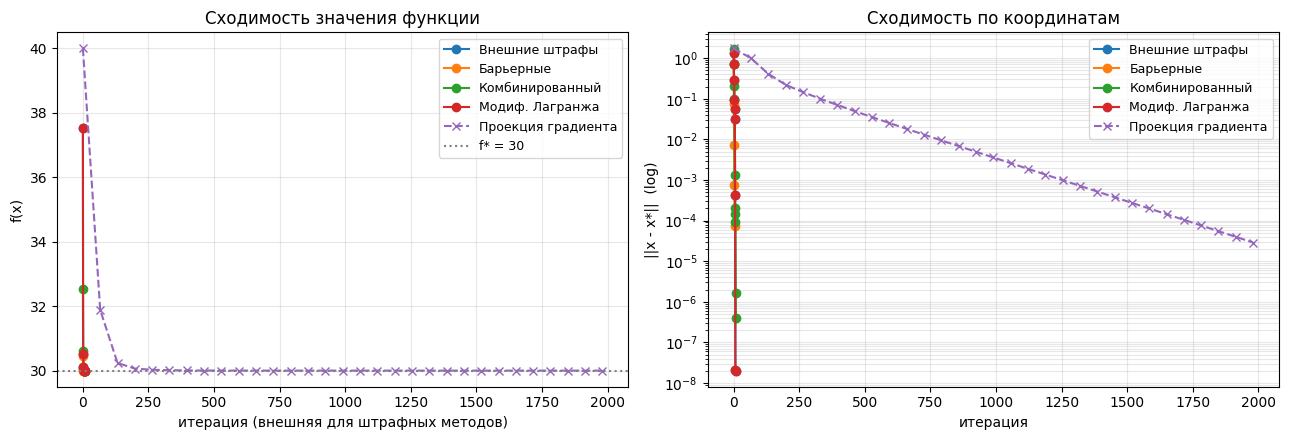

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

methods = [
    ("Внешние штрафы",       hist_ext, lambda h: h[2]),
    ("Барьерные",            hist_bar, lambda h: h[2]),
    ("Комбинированный",      hist_cmb, lambda h: h[2]),
    ("Модиф. Лагранжа",      hist_lag, lambda h: h[2]),
]

for name, hist, getx in methods:
    fs = [f(getx(h)) for h in hist]
    errs = [np.linalg.norm(getx(h) - x_star) for h in hist]
    axes[0].plot(fs, marker='o', label=name)
    axes[1].semilogy(errs, marker='o', label=name)

# для метода проекции градиента итерации внутренние, отдельно
fs_pg = [f(x) for x in hist_pg]
errs_pg = [np.linalg.norm(x - x_star) for x in hist_pg]
# покажем каждую 20-ю точку, чтобы шкалы были сопоставимы
step = max(1, len(hist_pg)//30)
axes[0].plot(range(0, len(fs_pg), step), fs_pg[::step], marker='x', label="Проекция градиента", linestyle='--')
axes[1].semilogy(range(0, len(errs_pg), step), errs_pg[::step], marker='x', label="Проекция градиента", linestyle='--')

axes[0].axhline(30, color='gray', linestyle=':', label='f* = 30')
axes[0].set_xlabel("итерация (внешняя для штрафных методов)")
axes[0].set_ylabel("f(x)")
axes[0].set_title("Сходимость значения функции")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("итерация")
axes[1].set_ylabel("||x - x*||  (log)")
axes[1].set_title("Сходимость по координатам")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('convergence.png', dpi=110, bbox_inches='tight')
plt.show()


## Траектории методов в плоскости $(x_1, x_2)$

Чтобы наглядно увидеть, как работает каждый метод, спроецируем траектории на плоскость первых двух координат и нарисуем сверху линии уровня $f$ при $x_3 = 1$ и границу проекции ограничения $g_1$.


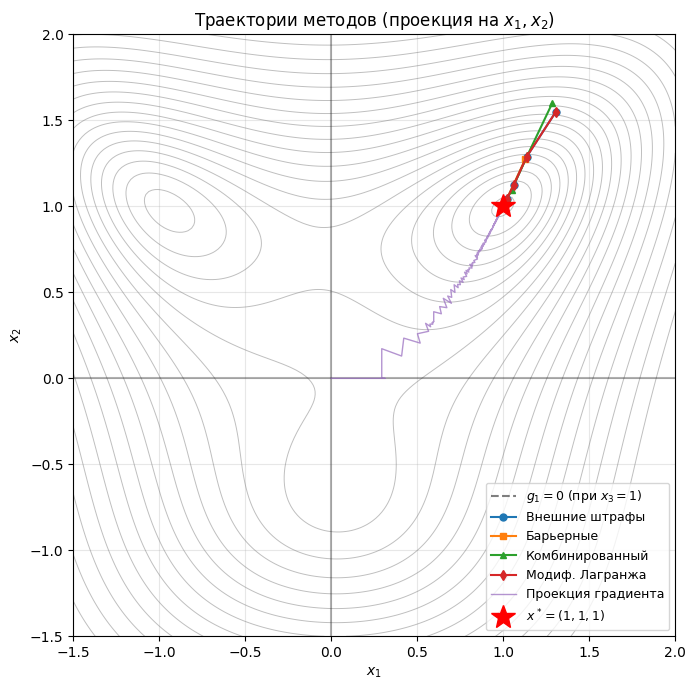

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

# линии уровня f при x3 = 1
xx = np.linspace(-1.5, 2.0, 200)
yy = np.linspace(-1.5, 2.0, 200)
X1, X2 = np.meshgrid(xx, yy)
Z = a*(X1**2 - X2)**2 + b*(X1-1)**2 + a*(X2**2 - 1)**2 + b*(X2-1)**2 + f0
cs = ax.contour(X1, X2, Z, levels=np.logspace(np.log10(31), np.log10(1000), 20),
                colors='gray', alpha=0.5, linewidths=0.7)

# граница g_1 при x_3 = 1: x1^2 + x2^2 = 8
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.sqrt(8)*np.cos(theta), np.sqrt(8)*np.sin(theta), 'k--', alpha=0.5, label='$g_1=0$ (при $x_3=1$)')

# оси (границы x1>=0, x2>=0)
ax.axhline(0, color='k', alpha=0.3)
ax.axvline(0, color='k', alpha=0.3)

# траектории
def trace(hist, getx):
    pts = np.array([getx(h)[:2] for h in hist])
    return pts

t_ext = trace(hist_ext, lambda h: h[2])
t_bar = trace(hist_bar, lambda h: h[2])
t_cmb = trace(hist_cmb, lambda h: h[2])
t_lag = trace(hist_lag, lambda h: h[2])
t_pg  = np.array([x[:2] for x in hist_pg])

ax.plot(t_ext[:,0], t_ext[:,1], 'o-', label='Внешние штрафы', markersize=5)
ax.plot(t_bar[:,0], t_bar[:,1], 's-', label='Барьерные', markersize=5)
ax.plot(t_cmb[:,0], t_cmb[:,1], '^-', label='Комбинированный', markersize=5)
ax.plot(t_lag[:,0], t_lag[:,1], 'd-', label='Модиф. Лагранжа', markersize=5)
ax.plot(t_pg[:,0], t_pg[:,1], '-', alpha=0.7, label='Проекция градиента', linewidth=1)

ax.plot(1, 1, 'r*', markersize=18, label='$x^*=(1,1,1)$', zorder=5)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Траектории методов (проекция на $x_1, x_2$)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-1.5, 2.0)
ax.set_ylim(-1.5, 2.0)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('trajectories.png', dpi=110, bbox_inches='tight')
plt.show()


## Проверка решения на допустимость

Финальная проверка для каждого метода.


In [ ]:
print(f"{'Метод':<22} {'g1(x)':>10} {'g2(x)':>10} {'g3(x)':>10} {'g4(x)':>10}  допустим?")
print("-"*80)
for name, x, _ in results:
    gs = [g(x) for g in G]
    ok = "да" if feasible(x, tol=1e-6) else "нарушено"
    print(f"{name:<22} " + " ".join(f"{v:>10.2e}" for v in gs) + f"   {ok}")


Метод                       g1(x)      g2(x)      g3(x)      g4(x)  допустим?
--------------------------------------------------------------------------------
Внешние штрафы          -6.00e+00  -1.00e+00  -1.00e+00  -1.00e+00   да
Барьерные функции       -6.00e+00  -1.00e+00  -1.00e+00  -1.00e+00   да
Комбинированный         -6.00e+00  -1.00e+00  -1.00e+00  -1.00e+00   да
Модиф. ф-я Лагранжа     -6.00e+00  -1.00e+00  -1.00e+00  -1.00e+00   да
Проекция градиента      -6.00e+00  -1.00e+00  -1.00e+00  -1.00e+00   да


## Выводы

1. **Условный минимум**: $x^* = (1, 1, 1)^T$, $f^* = 30$. Все ограничения в этой точке неактивны (запас по $g_1$ равен 6, по $g_2,g_3,g_4$ — единице). Множители Лагранжа все нулевые. Условный минимум совпадает с безусловным.

2. **Метод внешних штрафов** при выбранной стартовой точке $(2, 2, -0.5)$ за 9 внешних итераций сошёлся к $(1,1,1)$ с точностью $\sim 10^{-8}$. Видимый «дефект» метода — нарушение ограничений в финальной точке — здесь не проявился, потому что решение лежит глубоко внутри области.

3. **Барьерный метод** даёт точки, всегда лежащие внутри области. Сошёлся за 5 внешних итераций до точности $\sim 10^{-4}$ по координатам — естественное ограничение метода: с убыванием $r$ функция становится сильно овражной, и тонко сходиться к границе мешает.

4. **Комбинированный метод** с двумя независимыми параметрами ($r_p$ растёт, $r_b$ убывает) дал лучшую точность среди штрафных методов и аккуратно сошёлся к $(1,1,1)$ за 10 итераций.

5. **Модифицированная функция Лагранжа** в нашей задаче поведенчески идентична методу внешних штрафов: множители $\mu^k$ остаются нулевыми, поскольку в финальной точке все $g_j < 0$. Это согласуется с теорией (см. Замечание 4.2 п. 3 методички). Преимущества модиф. Лагранжа становятся видны на задачах с активными ограничениями.

6. **Метод проекции градиента** медленный — почти 2000 итераций до точности $10^{-5}$ по координатам. Причина — овражность функции Розенброка: метод первого порядка зигзагует вдоль дна оврага. Если бы вместо градиентного шага использовался метод второго порядка (Ньютон), сходимость была бы существенно быстрее.

**Сравнение по числу внешних итераций**: барьерный (5) ≲ комбинированный (10) ≈ штрафной = Лагранж (9) ≪ проекция градиента (~2000).

**Сравнение по точности** ($\|x^* - (1,1,1)\|$): штрафной = Лагранж (~$10^{-8}$) > комбинированный (~$10^{-7}$) > проекция градиента (~$10^{-5}$) > барьерный (~$10^{-4}$).

Все методы дали допустимые решения с одинаковым значением $f^* = 30$. Отличия проявляются именно в точности по координатам и числе итераций.
